<a href="https://colab.research.google.com/github/indahkhairunnisah-afk/Praktikum-Pemodelan-Simulasi-dan-Simulasi/blob/main/Tugas_Praktikum_2_Polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Modul Praktikum


Analisis Regresi Linier, Regresi Linier Berganda, dan Evaluasi Model (MAE, MSE, RMSE)

Modul ini bertujuan untuk membantu mahasiswa memahami cara membangun model regresi linier sederhana dan regresi linier berganda serta mengevaluasi performa model menggunakan beberapa ukuran kesalahan seperti MAE, MSE, dan RMSE.

## Tujuan Praktikum
Setelah mengikuti praktikum ini mahasiswa mampu:

1. Memahami konsep regresi linier sederhana
2. Membangun model regresi menggunakan Python
3. Membangun model regresi linier berganda
4. Menghitung MAE, MSE, dan RMSE
5. Menginterpretasikan kinerja model

##Import Library


In [271]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## Membaca Dataset

Dataset yang digunakan misalnya dataset harga rumah.

In [272]:
data = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/1D_Porosity.csv')
data.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


## Informasi Dataset

In [273]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth      40 non-null     float64
 1   Nporosity  40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


##Statistika Deskriptif


In [274]:
data.describe()

,Depth,Nporosity
count,40.000000,40.000000
mean,5.125000,0.022250
std,2.922613,0.992111
min,0.250000,-2.080000
25%,2.687500,-0.757500
50%,5.125000,0.140000
75%,7.562500,0.742500
max,10.000000,2.350000


## Visualisasi Hubungan Variabel

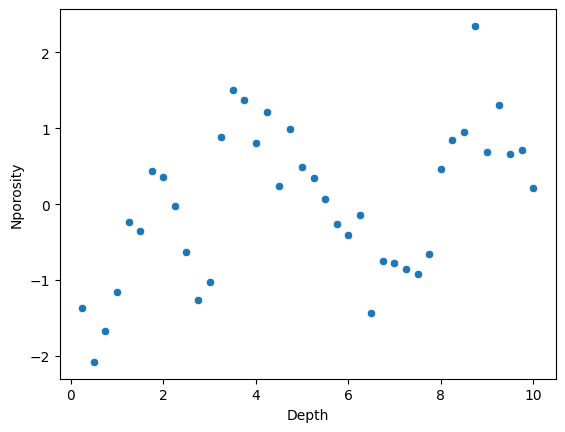

In [275]:
sns.scatterplot(x='Depth', y='Nporosity', data=data)
plt.show()

# Regresi Linier Sederhana

Model regresi:

Y = β0 + β1X + ε

## Menentukan Variabel

In [276]:
X = data[['Depth']]
y = data['Nporosity']

## Membuat Model Regresi

In [277]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [278]:
print('Intercept:', model.intercept_)
print('Koefisien:', model.coef_)

Intercept: -0.6919615384615387
Koefisien: [0.13935835]


## Melihat Koefisien Model

In [279]:
print('Depth:', model.intercept_)
print('Nporosity:', model.coef_)

Depth: -0.6919615384615387
Nporosity: [0.13935835]


In [280]:
y_pred = model.predict(X)
print(y_pred)


[-0.65712195 -0.62228236 -0.58744278 -0.55260319 -0.5177636  -0.48292402
 -0.44808443 -0.41324484 -0.37840525 -0.34356567 -0.30872608 -0.27388649
 -0.2390469  -0.20420732 -0.16936773 -0.13452814 -0.09968856 -0.06484897
 -0.03000938  0.00483021  0.03966979  0.07450938  0.10934897  0.14418856
  0.17902814  0.21386773  0.24870732  0.2835469   0.31838649  0.35322608
  0.38806567  0.42290525  0.45774484  0.49258443  0.52742402  0.5622636
  0.59710319  0.63194278  0.66678236  0.70162195]


##Membuat Visualisasi Model

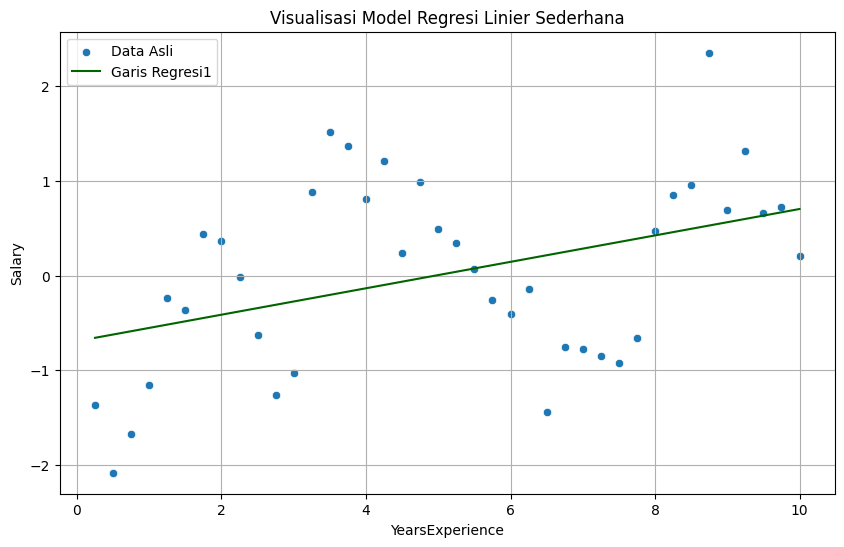

In [281]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='#006400', label='Garis Regresi1')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

##Prediksi
#### Mean Absolute Error (MAE) , MEan Squared Error (MSE) dan Root Mean Square Error (RMSE)

In [282]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print('MAE:', mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 0.7399434333958724
MSE: 0.7979390086772984
RMSE: 0.8932743188278158


Model regresi ini menunjukkan adanya tren positif antara masa kerja dan gaji, namun dengan akurasi yang relatif rendah karena data asli memiliki pola fluktuatif (naik-turun) yang tidak mampu ditangkap sepenuhnya oleh garis lurus. Nilai MAE (0,74) dan RMSE (0,89) menunjukkan bahwa rata-rata prediksi meleset sekitar 0,74 hingga 0,89 unit dari data aktual, di mana perbedaan nilai antara keduanya mengindikasikan adanya beberapa outlier atau simpangan yang cukup besar pada titik-titik tertentu. Secara keseluruhan, model ini memberikan gambaran umum yang baik tentang arah hubungan variabel, tetapi kurang presisi jika digunakan untuk prediksi individu karena data aslinya cenderung mengikuti pola non-linear atau polinomial daripada linear murni.

# Regresi Polynomial

Regresi polynomial merupakan pengembangan dari regresi linier yang digunakan untuk memodelkan hubungan nonlinier antara variabel independen dan variabel dependen. Jika hubungan antara variabel tidak dapat dijelaskan dengan garis lurus, maka regresi polynomial dapat digunakan dengan menambahkan pangkat dari variabel independen ke dalam model.
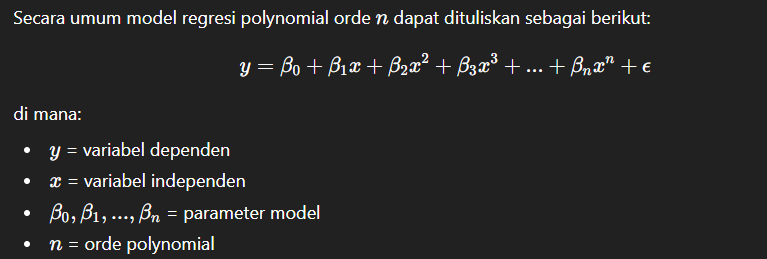

## Membuat model orde 2


In [283]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000e+00, 2.50000e-01, 6.25000e-02],
       [1.00000e+00, 5.00000e-01, 2.50000e-01],
       [1.00000e+00, 7.50000e-01, 5.62500e-01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00],
       [1.00000e+00, 1.25000e+00, 1.56250e+00],
       [1.00000e+00, 1.50000e+00, 2.25000e+00],
       [1.00000e+00, 1.75000e+00, 3.06250e+00],
       [1.00000e+00, 2.00000e+00, 4.00000e+00],
       [1.00000e+00, 2.25000e+00, 5.06250e+00],
       [1.00000e+00, 2.50000e+00, 6.25000e+00],
       [1.00000e+00, 2.75000e+00, 7.56250e+00],
       [1.00000e+00, 3.00000e+00, 9.00000e+00],
       [1.00000e+00, 3.25000e+00, 1.05625e+01],
       [1.00000e+00, 3.50000e+00, 1.22500e+01],
       [1.00000e+00, 3.75000e+00, 1.40625e+01],
       [1.00000e+00, 4.00000e+00, 1.60000e+01],
       [1.00000e+00, 4.25000e+00, 1.80625e+01],
       [1.00000e+00, 4.50000e+00, 2.02500e+01],
       [1.00000e+00, 4.75000e+00, 2.25625e+01],
       [1.00000e+00, 5.00000e+00, 2.50000e+01],
       [1.00000e+00, 5.25000e+00, 2.7562

Membuat Model Regresi Orde 2

In [284]:
#Membuat model orde 2
model2 = LinearRegression()

model2.fit(X_poly, y)

LinearRegression()

In [285]:
y_pred2 = model2.predict(X_poly)
print(y_pred2)

[-9.52657666e-01 -8.72351045e-01 -7.94437427e-01 -7.18916810e-01
 -6.45789195e-01 -5.75054582e-01 -5.06712970e-01 -4.40764360e-01
 -3.77208752e-01 -3.16046146e-01 -2.57276541e-01 -2.00899939e-01
 -1.46916338e-01 -9.53257381e-02 -4.61281405e-02  6.76455444e-04
  4.50880496e-02  8.71066421e-02  1.26732233e-01  1.63964822e-01
  1.98804409e-01  2.31250995e-01  2.61304578e-01  2.88965160e-01
  3.14232741e-01  3.37107319e-01  3.57588896e-01  3.75677471e-01
  3.91373044e-01  4.04675616e-01  4.15585186e-01  4.24101754e-01
  4.30225321e-01  4.33955885e-01  4.35293448e-01  4.34238009e-01
  4.30789569e-01  4.24948127e-01  4.16713683e-01  4.06086237e-01]


Melihat Koefesien Model 2

In [286]:
print('Intercept:', model2.intercept_)
print('Koefisien:', model2.coef_)

Intercept: -1.0353572874493948
Koefisien: [ 0.          0.33558449 -0.01914401]


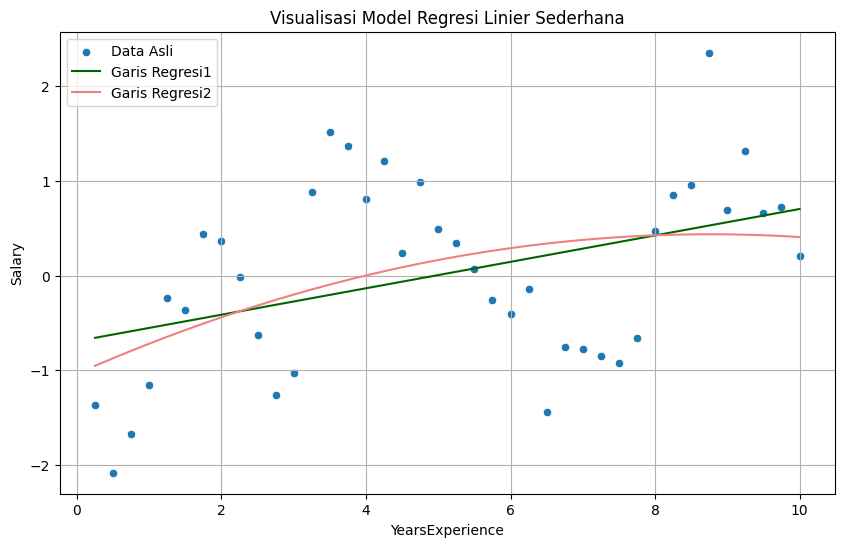

In [287]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='#006400', label='Garis Regresi1')
plt.plot(X, y_pred2, color='#F08080', label='Garis Regresi2')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

##Prediksi 2
#### Mean Absolute Error (MAE) , MEan Squared Error (MSE) dan Root Mean Square Error (RMSE)

In [288]:
mae2 = mean_absolute_error(y, y_pred2)
mse2 = mean_squared_error(y, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y, y_pred2))

print('MAE2:', mae2)
print('MSE2:',mse2)
print('RMSE2:',rmse2)

MAE2: 0.7400630834826277
MSE2: 0.7776418670853376
RMSE2: 0.881840046201882


Penggunaan model Regresi Polinomial Orde 2 (Garis Regresi 2 berwarna merah muda) menunjukkan upaya untuk menangkap kelengkungan data, di mana model ini sedikit lebih baik dalam menekan kesalahan kuadrat ( MSE: 0,77 dan RMSE: 0,88 ) dibandingkan model linier sebelumnya, namun secara keseluruhan belum memberikan peningkatan akurasi yang signifikan. Hal ini terlihat dari nilai MAE (0,74) yang hampir identik dengan model linear, mengindikasikan bahwa meskipun garis melengkung tersebut mencoba mengikuti pola data, penyebaran titik-titik asli yang sangat fluktuatif tetap menyebabkan rata-rata kesalahan prediksi yang sama besarnya. Kurva Orde 2 ini cenderung melandai di akhir (sekitar tahun ke-8 hingga ke-10), yang secara statistik mencoba menyesuaikan diri dengan penurunan data di area tersebut, tetapi tetap gagal menangkap pola "gelombang" naik-turun yang berulang dalam kumpulan data ini.

##Membuat Model Orde 3

In [289]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01],
       [1.00000000e+00, 2.75000000e+00, 7.56250000e+00, 2.07968750e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01],
       [1.00000000e+00, 3.25000000e+00, 1.05625000e+01, 3.43281250e+01],
       [1.00000000e+00, 3.50000000e+00, 1.22500000e

Membuat Model Regresi Orde 3

In [290]:
#Membuat model orde 3
model3 = LinearRegression()

model3.fit(X_poly, y)

LinearRegression()

In [291]:
y_pred3 = model3.predict(X_poly)
print(y_pred3)

[-1.97454493 -1.57981146 -1.22884294 -0.91940306 -0.64925549 -0.41616391
 -0.217892   -0.05220344  0.0831381   0.19036894  0.27172539  0.32944379
  0.36576044  0.38291169  0.38313384  0.36866321  0.34173614  0.30458894
  0.25945793  0.20857944  0.15418979  0.09852529  0.04382228 -0.00768293
 -0.05375402 -0.09215466 -0.12064853 -0.13699931 -0.13897068 -0.12432632
 -0.0908299  -0.0362451   0.0416644   0.14513492  0.27640278  0.43770431
  0.63127582  0.85935364  1.1241741   1.4279735 ]


Melihat Koefisien Model 3

In [292]:
print('Intercept:', model3.intercept_)
print('Koefisien:', model3.coef_)

Intercept: -2.415279680490101
Koefisien: [ 0.          1.85792331 -0.3859008   0.0238541 ]


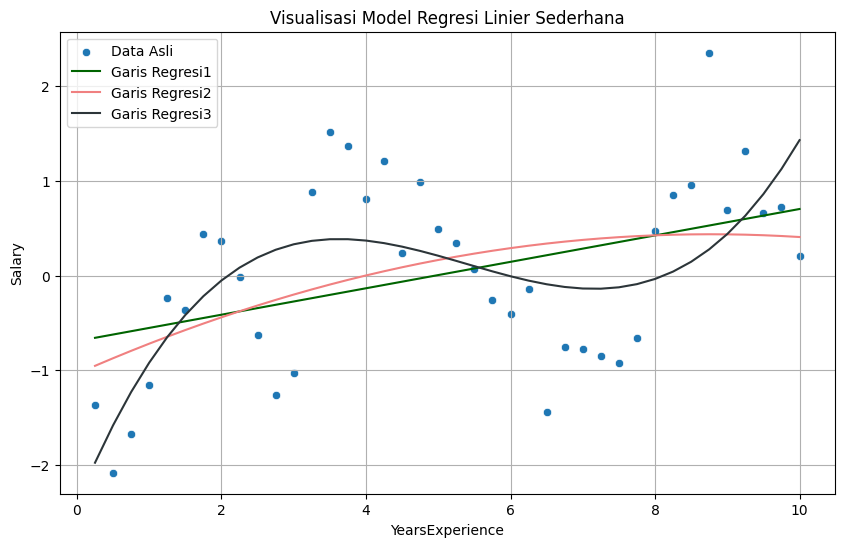

In [293]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='#006400', label='Garis Regresi1')
plt.plot(X, y_pred2, color='#F08080', label='Garis Regresi2')
plt.plot(X, y_pred3, color='#2C3539', label='Garis Regresi3')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

Prediksi 3

In [294]:
mae3 = mean_absolute_error(y, y_pred3)
mse3 = mean_squared_error(y, y_pred3)
rmse3 = np.sqrt(mean_squared_error(y, y_pred3))

print('MAE3:', mae3)
print('MSE3:',mse3)
print('RMSE3:',rmse3)

MAE3: 0.6199845079521994
MSE3: 0.5761954211496901
RMSE3: 0.7590753725090086


Model Regresi Polinomial Orde 3 (Garis Regresi 3 berwarna hitam) menunjukkan peningkatan akurasi yang signifikan dibandingkan model sebelumnya karena kemampuan menangkap pola gelombang ( kurva S ) pada data. Hal ini dibuktikan dengan penurunan drastis pada seluruh kesalahan metrik, di mana MAE (0,62) , MSE (0,58) , dan RMSE (0,76) mencapai nilai setinggi terendah ini, menandakan bahwa jarak antara titik data asli dengan garis prediksi semakin rapat. Secara visual, kurva ini jauh lebih fleksibel karena mampu mengikuti tren kenaikan di awal, penurunan di tengah (sekitar tahun ke-4 hingga ke-7), dan kembali naik di akhir, sehingga model Orde 3 ini jauh lebih representatif untuk menjelaskan hubungan antara pengalaman kerja dan gaji dalam dataset yang fluktuatif ini.

##Membuat Model Orde 4

In [295]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01,
        3.90625000e+01],
       [1.00000000e+00, 2.7500

Membuat Model Regresi Orde 4

In [296]:
#Membuat model orde 4
model4 = LinearRegression()

model4.fit(X_poly, y)

LinearRegression()

In [297]:
y_pred4 = model4.predict(X_poly)
print(y_pred4)

[-2.21993535 -1.69936064 -1.25235539 -0.87292415 -0.55528031 -0.29384611
 -0.08325262  0.08166025  0.20584375  0.29404028  0.3507834   0.38039785
  0.38699951  0.37449542  0.34658379  0.30675398  0.25828651  0.20425308
  0.14751651  0.09073082  0.03634117 -0.01341613 -0.05651359 -0.09113256
 -0.11566325 -0.12870471 -0.1290648  -0.11576025 -0.08801661 -0.0452683
  0.01284145  0.08646055  0.17552809  0.27977431  0.39872059  0.53167949
  0.67775474  0.8358412   1.00462492  1.18258308]


Melihat Koefisien Model 4

In [298]:
print('Intercept:', model4.intercept_)
print('Koefisien:', model4.coef_)

Intercept: -2.820283811139648
Koefisien: [ 0.00000000e+00  2.56942257e+00 -6.89355799e-01  6.95205274e-02
 -2.22763062e-03]


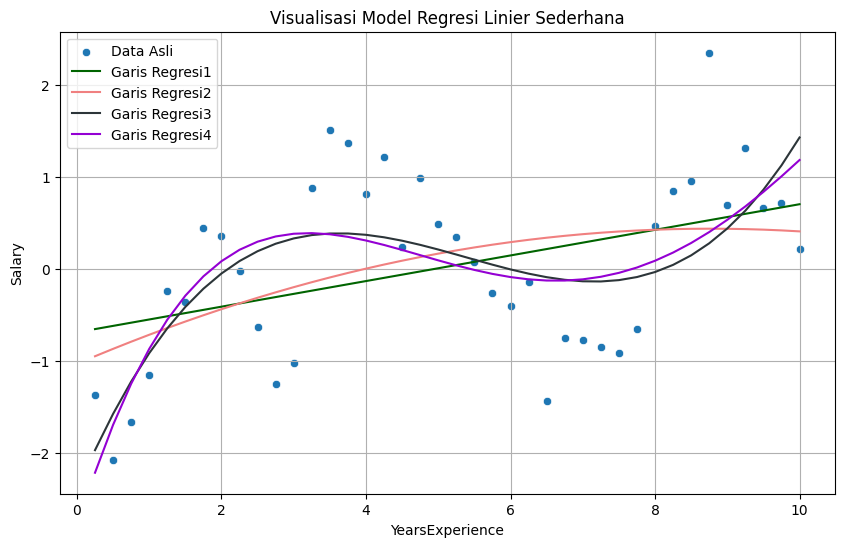

In [299]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='#006400', label='Garis Regresi1')
plt.plot(X, y_pred2, color='#F08080', label='Garis Regresi2')
plt.plot(X, y_pred3, color='#2C3539', label='Garis Regresi3')
plt.plot(X, y_pred4, color='#9400D3', label='Garis Regresi4')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

Prediksi 4

In [300]:
mae4 = mean_absolute_error(y, y_pred4)
mse4 = mean_squared_error(y, y_pred4)
rmse4 = np.sqrt(mean_squared_error(y, y_pred4))

print('MAE4:', mae4)
print('MSE4:',mse4)
print('RMSE4:',rmse4)

MAE4: 0.6104172796114554
MSE4: 0.565152739676581
RMSE4: 0.751766412974523


Model Regresi Polinomial Orde 4 (Garis Regresi 4 berwarna ungu) memberikan hasil yang paling akurat dibandingkan model ketiga sebelumnya, dengan nilai kesalahan terendah yaitu MAE (0,61) , MSE (0,56) , dan RMSE (0,75) . Secara visual, kurva ini memiliki titik-titik lebih tinggi untuk beradaptasi dengan radius data yang ekstrem, terutama pada area awal (tahun ke-0 hingga ke-2) dan akhir (tahun ke-8 hingga ke-10), di mana garis ungu terlihat lebih "melengkung tajam" mengikuti sebaran titik-titik data dibandingkan garis hitam (Orde 3). Meskipun peningkatannya tidak sedrastis dari Orde 2 ke Orde 3, model Orde 4 ini berhasil meminimalkan residu (selisih prediksi) lebih jauh lagi, menjadikannya model yang paling fit secara matematis untuk dataset ini tanpa terlihat mengalami overfitting yang berlebihan.

##Membuat Model 5

In [301]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03, 9.76562500e-04],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02, 3.12500000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01, 2.37304688e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00, 3.05175781e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00, 7.59375000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00, 1.64130859e+01],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01, 3.20000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01, 

Membuat Model Regresi Orde 5

In [302]:
#Membuat model orde 5
model5 = LinearRegression()

model5.fit(X_poly, y)

LinearRegression()

In [303]:
y_pred5 = model5.predict(X_poly)
print(y_pred5)

[-1.32620662 -1.49311555 -1.48031049 -1.33655998 -1.10399591 -0.81850468
 -0.51011835 -0.20340586  0.08213581  0.33169052  0.53473173  0.68463137
  0.77826865  0.8156389   0.79946241  0.73479322  0.62862798  0.48951478
  0.32716195  0.15204693 -0.02497494 -0.19306157 -0.34177529 -0.46147403
 -0.5437025  -0.58158333 -0.57020828 -0.50702938 -0.39225013 -0.22921663
 -0.02480879  0.21016849  0.46059421  0.70664004  0.92337915  1.0803951
  1.14139057  1.0637963   0.79837983  0.28885435]


Melihat Koefisien Model 5

In [304]:
print('Intercept:', model5.intercept_)
print('Koefisien:', model5.coef_)

Intercept: -0.9237873399842297
Koefisien: [ 0.         -2.16243376  2.38459902 -0.71490841  0.0833085  -0.003338  ]


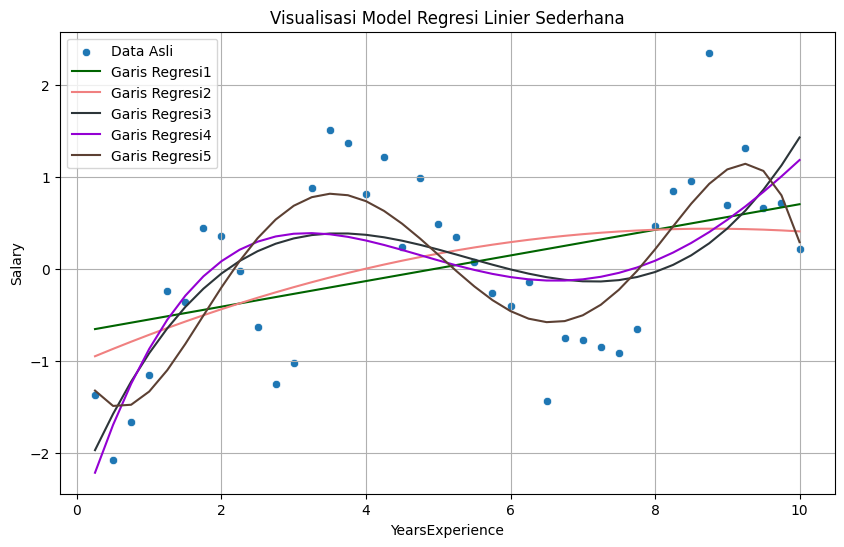

In [305]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='#006400', label='Garis Regresi1')
plt.plot(X, y_pred2, color='#F08080', label='Garis Regresi2')
plt.plot(X, y_pred3, color='#2C3539', label='Garis Regresi3')
plt.plot(X, y_pred4, color='#9400D3', label='Garis Regresi4')
plt.plot(X, y_pred5, color='#5C4033', label='Garis Regresi5')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

Prediksi 5

In [306]:
mae5 = mean_absolute_error(y, y_pred5)
mse5 = mean_squared_error(y, y_pred5)
rmse5 = np.sqrt(mean_squared_error(y, y_pred5))

print('MAE5:', mae5)
print('MSE5:',mse5)
print('RMSE5:',rmse5)

MAE5: 0.4844700295770121
MSE5: 0.4110660686255764
RMSE5: 0.641144343050437


Model Regresi Polinomial Orde 5 (Garis Regresi 5 berwarna cokelat) menunjukkan performa yang paling unggul dibandingkan seluruh model sebelumnya, dengan penurunan nilai kesalahan yang sangat signifikan pada MAE (0,48) , MSE (0,41) , dan RMSE (0,64) . Secara visual, kurva ini adalah yang pertama yang benar-benar mampu "mengikuti" pola osilasi atau gelombang naik-turun data secara mendetail—mulai dari puncak di tahun ke-3 hingga ke-4, lembah di tahun ke-6 hingga ke-7, dan kembali naik di akhir. Keberhasilan model ini menurunkan MAE hingga di bawah 0,5 menunjukkan bahwa rata-rata selisih prediksi dengan data aktual kini jauh lebih rapat, menjadikan model yang paling presisi dalam menangkap karakteristik data yang sangat fluktuatif ini.

Seiring bertambahnya tingkat polinomial dari Orde 1 hingga 5, model bertransformasi dari yang semula terlalu kaku ( underfitting ) menjadi sangat fleksibel. Orde 5 saat ini memberikan hasil terbaik, namun perlu diperhatikan agar tidak menaikkan tingkat polinomial terlalu tinggi lagi guna menghindari risiko overfitting (di mana model terlalu menghafal data latihan dan kehilangan kemampuan generalisasi).